In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

# Number of ICD-10 codes per claim:

In [2]:
def read_and_count(data):
    df = pd.read_csv(data, header=None)
    sum_of_claims = df[1].values.sum()  # Sum of the second column
    return sum_of_claims

In [3]:
directory_path = '/Users/ahmadrezaie/papers/Synthetic_Data_Gen/data/input/IQVIA'

search_pattern = os.path.join(directory_path, 'diag*.csv')

# Use glob.glob to find all files matching the pattern
matching_files = glob.glob(search_pattern)

sums_dict = {}

print("Found CSV files:")
for file in matching_files:
    sums_dict[os.path.basename(file)] = read_and_count(file)



Found CSV files:


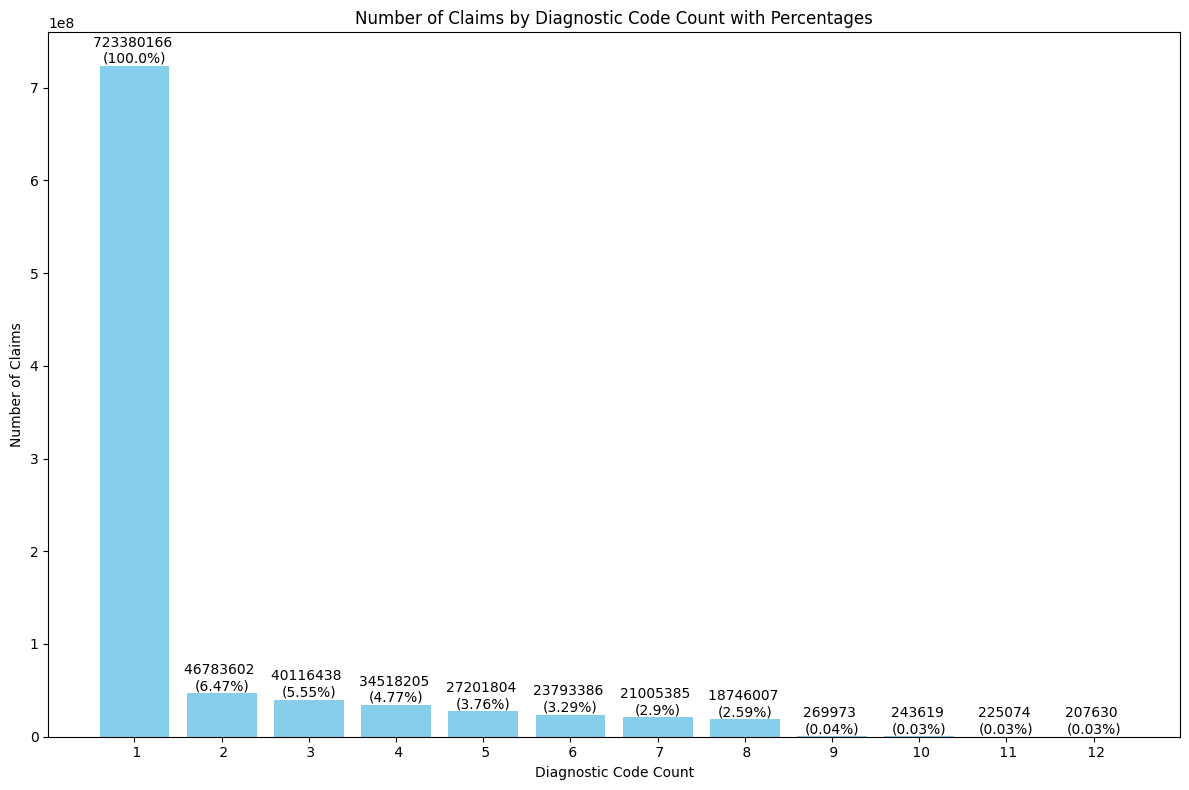

In [4]:

# Find the maximum sum of claims to calculate percentages
max_sum = max(sums_dict.values())

# Sort the dictionary by its values (sum of claims) in descending order
sorted_sums_dict = dict(sorted(sums_dict.items(), key=lambda item: item[1], reverse=True))

# Calculate the percentage of each sum relative to the maximum
percentages_dict = {key: (value / max_sum) * 100 for key, value in sorted_sums_dict.items()}

# Generate generic labels for the x-axis
generic_labels = [f" {i+1}" for i in range(len(sorted_sums_dict))]

# Now, visualize the sorted data using matplotlib
plt.figure(figsize=(12, 8))
bars = plt.bar(generic_labels, sorted_sums_dict.values(), color='skyblue')

# Add text annotations on top of each bar for the number of claims and percentage
for bar, sum_of_claims in zip(bars, sorted_sums_dict.values()):
    percentage = (sum_of_claims / max_sum) * 100
    plt.text(bar.get_x() + bar.get_width() / 2, sum_of_claims, 
             f"{round(sum_of_claims, 2)} \n({round(percentage, 2)}%)", 
             ha='center', va='bottom')

plt.xlabel('Diagnostic Code Count')
plt.ylabel('Number of Claims')
plt.title('Number of Claims by Diagnostic Code Count with Percentages')
plt.tight_layout()
plt.show()

Those numbers are comming from summing up the number of accurances of each ICD-10 code in diag_x column. For example, the first one (723 million) is the sum of numbers of occurances of all ICD-10 codes in diag_1.

# Removing Duplicate ICD-9 and ICD-10 to avoid confusion:

* set the cutoff to 4k or 5k
* 

In [5]:

directory_path = '/Users/ahmadrezaie/papers/Synthetic_Data_Gen/data/input/IQVIA'
search_pattern = os.path.join(directory_path, 'diag*.csv')

# Use glob.glob to find all files matching the pattern
matching_files = glob.glob(search_pattern)

# List to hold data from all files
dataframes_list = []

# Read each file and append to the list
for file in matching_files:
    df = pd.read_csv(file, header=None)
    dataframes_list.append(df)

# Concatenate all DataFrames into a single DataFrame
combined_df = pd.concat(dataframes_list, ignore_index=True)

# Group by the first column and sum the second column for each group
aggregated_df = combined_df.groupby(0).agg({1: 'sum'}).reset_index()

# Now, you can visualize the aggregated data (sum of the second column)
plt.figure(figsize=(10, 6))
plt.bar(aggregated_df[0].astype(str), aggregated_df[1], color='skyblue')
plt.xlabel('Group (First Column)')
plt.ylabel('Sum of Second Column')
plt.title('Sum of Second Column by Group')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

In [6]:
df_all = pd.read_csv("/Users/ahmadrezaie/papers/Synthetic_Data_Gen/data/input/IQVIA/Diags_all.csv", header = None)
df_all.head()

,0,1,2
0,40165321,V202,UNSPECIFIED MOTORCYCLE RIDER INJURED IN COLLIS...
1,31892993,V700,DRIVER OF BUS INJURED IN COLLISION WITH PEDEST...
2,21788529,I10,ESSENTIAL (PRIMARY) HYPERTENSION
3,19497471,Z0000,ENCOUNTER FOR GENERAL ADULT MEDICAL EXAMINATIO...
4,13272519,Z00129,ENCOUNTER FOR ROUTINE CHILD HEALTH EXAMINATION...


In [69]:
sorted_aggregated_df = aggregated_df.sort_values(by=1, ascending=False, )
sorted_aggregated_df.reset_index(drop=True, inplace=True)

sorted_aggregated_df

,0,1
0,V202,40165321
1,V700,31892993
2,I10,21788529
3,Z0000,19497471
4,Z00129,13272519
...,...,...
55687,T475X6D,1
55688,T475X6A,1
55689,S6113,1
55690,S61141D,1


The numbers between df_all and the one aggregated from the seperate files match, so I will continuw with df_all instead because it already has icd_desc.

In [7]:
df_all

,0,1,2
0,40165321,V202,UNSPECIFIED MOTORCYCLE RIDER INJURED IN COLLIS...
1,31892993,V700,DRIVER OF BUS INJURED IN COLLISION WITH PEDEST...
2,21788529,I10,ESSENTIAL (PRIMARY) HYPERTENSION
3,19497471,Z0000,ENCOUNTER FOR GENERAL ADULT MEDICAL EXAMINATIO...
4,13272519,Z00129,ENCOUNTER FOR ROUTINE CHILD HEALTH EXAMINATION...
...,...,...,...
55686,1,B9731,LENTIVIRUS AS THE CAUSE OF DISEASES CLASSIFIED...
55687,1,E093512,DRUG OR CHEMICAL INDUCED DIABETES MELLITUS WIT...
55688,1,E093519,DRUG OR CHEMICAL INDUCED DIABETES MELLITUS WIT...
55689,1,F18259,INHALANT DEPENDENCE WITH INHALANT-INDUCED PSYC...


In [8]:
# removing the ICD-10s bellow 40k:

df_all_filtered = df_all[df_all[0] >= 40000]


df_all_filtered.reset_index(drop=True, inplace=True)
df_all_filtered

,0,1,2
0,40165321,V202,UNSPECIFIED MOTORCYCLE RIDER INJURED IN COLLIS...
1,31892993,V700,DRIVER OF BUS INJURED IN COLLISION WITH PEDEST...
2,21788529,I10,ESSENTIAL (PRIMARY) HYPERTENSION
3,19497471,Z0000,ENCOUNTER FOR GENERAL ADULT MEDICAL EXAMINATIO...
4,13272519,Z00129,ENCOUNTER FOR ROUTINE CHILD HEALTH EXAMINATION...
...,...,...,...
2325,40165,Z3A34,34 WEEKS GESTATION OF PREGNANCY
2326,40127,C252,MALIGNANT NEOPLASM OF TAIL OF PANCREAS
2327,40107,G9009,OTHER IDIOPATHIC PERIPHERAL AUTONOMIC NEUROPATHY
2328,40080,K5903,DRUG INDUCED CONSTIPATION


In [16]:
# sampling 5 for generation testing:


sampled_rows = df_all_filtered.sample(5)

# Return values in the second column of the sampled rows in a list
sample_5_icds = sampled_rows.iloc[:, 1].tolist()
#sample_5_icds

sampled_rows

,0,1,2
1291,94000,B009,"HERPESVIRAL INFECTION, UNSPECIFIED"
334,472643,H903,"SENSORINEURAL HEARING LOSS, BILATERAL"
440,341632,B182,CHRONIC VIRAL HEPATITIS C
145,892745,F332,"MAJOR DEPRESSIVE DISORDER, RECURRENT SEVERE WI..."
221,630768,G894,CHRONIC PAIN SYNDROME


In [21]:
all_text_third_column = sampled_rows.iloc[:, 2].to_list()
all_text_third_column

['HERPESVIRAL INFECTION, UNSPECIFIED',
 'SENSORINEURAL HEARING LOSS, BILATERAL',
 'CHRONIC VIRAL HEPATITIS C',
 'MAJOR DEPRESSIVE DISORDER, RECURRENT SEVERE WITHOUT PSYCHOTIC FEATURES',
 'CHRONIC PAIN SYNDROME']

In [9]:
# how many of those belong to V and E classes?

# Count the number of entries in the first column starting with 'V'
count_v = df_all_filtered[df_all_filtered[1].str.startswith('V')].shape[0]

# Count the number of entries in the first column starting with 'E'
count_e = df_all_filtered[df_all_filtered[1].str.startswith('E')].shape[0]

# Print the counts
print(f"Number of entries starting with 'V': {count_v}")
print(f"Number of entries starting with 'E': {count_e}")


Number of entries starting with 'V': 100
Number of entries starting with 'E': 107


In [10]:
# Filter the DataFrame for entries starting with 'V'
v_entries = df_all_filtered[df_all_filtered[1].str.startswith('V')]

# Print details for entries starting with 'V'
print("Entries starting with 'V':")
for index, row in v_entries.iterrows():
    print(f"Index: {index}, First Column: {row[1]}, Second Column: {row[1]}, Third Column: {row[2]}")


Entries starting with 'V':
Index: 0, First Column: V202, Second Column: V202, Third Column: UNSPECIFIED MOTORCYCLE RIDER INJURED IN COLLISION WITH PEDESTRIAN OR ANIMAL IN NONTRAFFIC ACCIDENT
Index: 1, First Column: V700, Second Column: V700, Third Column: DRIVER OF BUS INJURED IN COLLISION WITH PEDESTRIAN OR ANIMAL IN NONTRAFFIC ACCIDENT
Index: 10, First Column: V571, Second Column: V571, Third Column: PASSENGER IN PICK-UP TRUCK OR VAN INJURED IN COLLISION WITH FIXED OR STATIONARY OBJECT IN NONTRAFFIC ACCIDENT
Index: 12, First Column: V221, Second Column: V221, Third Column: MOTORCYCLE PASSENGER INJURED IN COLLISION WITH TWO- OR THREE-WHEELED MOTOR VEHICLE IN NONTRAFFIC ACCIDENT
Index: 19, First Column: V762, Second Column: V762, Third Column: PERSON ON OUTSIDE OF BUS INJURED IN COLLISION WITH OTHER NONMOTOR VEHICLE IN NONTRAFFIC ACCIDENT
Index: 44, First Column: V222, Second Column: V222, Third Column: UNSPECIFIED MOTORCYCLE RIDER INJURED IN COLLISION WITH TWO- OR THREE-WHEELED MOTOR 

In [11]:
e_entries = df_all_filtered[df_all_filtered[1].str.startswith('E')]

# Print details for entries starting with 'E'
print("\nEntries starting with 'E':")
for index, row in e_entries.iterrows():
    print(f"Index: {index}, First Column: {row[0]}, Second Column: {row[1]}, Third Column: {row[2]}")


Entries starting with 'E':
Index: 6, First Column: 9890112, Second Column: E119, Third Column: TYPE 2 DIABETES MELLITUS WITHOUT COMPLICATIONS
Index: 8, First Column: 8061616, Second Column: E785, Third Column: HYPERLIPIDEMIA, UNSPECIFIED
Index: 14, First Column: 5618816, Second Column: E039, Third Column: HYPOTHYROIDISM, UNSPECIFIED
Index: 28, First Column: 3339880, Second Column: E1165, Third Column: TYPE 2 DIABETES MELLITUS WITH HYPERGLYCEMIA
Index: 50, First Column: 2286022, Second Column: E782, Third Column: MIXED HYPERLIPIDEMIA
Index: 56, First Column: 2160526, Second Column: E559, Third Column: VITAMIN D DEFICIENCY, UNSPECIFIED
Index: 74, First Column: 1874041, Second Column: E669, Third Column: OBESITY, UNSPECIFIED
Index: 75, First Column: 1853535, Second Column: E871, Third Column: HYPO-OSMOLALITY AND HYPONATREMIA
Index: 80, First Column: 1758285, Second Column: E7800, Third Column: PURE HYPERCHOLESTEROLEMIA, UNSPECIFIED
Index: 82, First Column: 1718699, Second Column: E860, T

## finding overlap between ICD9 and ICD10:

The data are gathered from:

ICD9: https://www.cms.gov/medicare/coding-billing/icd-10-codes/icd-9-cm-diagnosis-procedure-codes-abbreviated-and-full-code-titles

ICD10: https://www.cms.gov/medicare/coordination-benefits-recovery/overview/icd-code-lists

The problem is they updated ICD10 to avoid the duplication in V. 
Ask Niko to get the duplicated in IQVIA. It would be accurate based on the ICD versions they are using.

In [84]:
icd9 = pd.read_excel("/Users/ahmadrezaie/DalPhD/Research/note_taking_v2/data/input/ICDs/ICD9/CMS32_DESC_LONG_SHORT_DX.xlsx")
icd9

,DIAGNOSIS CODE,LONG DESCRIPTION,SHORT DESCRIPTION
0,0010,Cholera due to vibrio cholerae,Cholera d/t vib cholerae
1,0011,Cholera due to vibrio cholerae el tor,Cholera d/t vib el tor
2,0019,"Cholera, unspecified",Cholera NOS
3,0020,Typhoid fever,Typhoid fever
4,0021,Paratyphoid fever A,Paratyphoid fever a
...,...,...,...
14562,V9129,"Quadruplet gestation, unable to determine numb...",Quad gest-plac/sac undet
14563,V9190,"Other specified multiple gestation, unspecifie...",Mult gest-plac/sac NOS
14564,V9191,"Other specified multiple gestation, with two o...",Mult gest 2+ monochr NEC
14565,V9192,"Other specified multiple gestation, with two o...",Mult gest 2+ monoamn NEC


In [85]:
icd10 = pd.read_excel("/Users/ahmadrezaie/DalPhD/Research/note_taking_v2/data/input/ICDs/ICD10/Section111ValidICD10-Jan2024.xlsx")
icd10

,CODE,SHORT DESCRIPTION (VALID ICD-10 FY2024),LONG DESCRIPTION (VALID ICD-10 FY2024),NF EXCL
0,A000,"Cholera due to Vibrio cholerae 01, biovar chol...","Cholera due to Vibrio cholerae 01, biovar chol...",NaN
1,A001,"Cholera due to Vibrio cholerae 01, biovar eltor","Cholera due to Vibrio cholerae 01, biovar eltor",NaN
2,A009,"Cholera, unspecified","Cholera, unspecified",NaN
3,A0100,"Typhoid fever, unspecified","Typhoid fever, unspecified",NaN
4,A0101,Typhoid meningitis,Typhoid meningitis,NaN
...,...,...,...,...
73196,Y990,Civilian activity done for income or pay,Civilian activity done for income or pay,Y
73197,Y991,Military activity,Military activity,Y
73198,Y992,Volunteer activity,Volunteer activity,Y
73199,Y998,Other external cause status,Other external cause status,Y


In [87]:
duplicate = pd.merge(icd9, icd10, left_on='DIAGNOSIS CODE', right_on='CODE')
duplicate.head()

,DIAGNOSIS CODE,LONG DESCRIPTION,SHORT DESCRIPTION,CODE,SHORT DESCRIPTION (VALID ICD-10 FY2024),LONG DESCRIPTION (VALID ICD-10 FY2024),NF EXCL
0,E030,Unspecified activity,Activity NOS,E030,Congenital hypothyroidism with diffuse goiter,Congenital hypothyroidism with diffuse goiter,NaN
1,E8020,Railway accident involving derailment without ...,RR acc w derail-employee,E8020,Unspecified porphyria,Unspecified porphyria,NaN
2,E8021,Railway accident involving derailment without ...,RR acc w derail-passeng,E8021,Acute intermittent (hepatic) porphyria,Acute intermittent (hepatic) porphyria,NaN
3,E8029,Railway accident involving derailment without ...,RR acc w derail-pers NOS,E8029,Other porphyria,Other porphyria,NaN
4,E8300,Accident to watercraft causing submersion inju...,Boat acc w submers-unpow,E8300,"Disorder of copper metabolism, unspecified","Disorder of copper metabolism, unspecified",NaN


In [88]:
duplicates_starting_with_v = duplicate[duplicate['DIAGNOSIS CODE'].str.startswith('V')]
duplicates_starting_with_v

,DIAGNOSIS CODE,LONG DESCRIPTION,SHORT DESCRIPTION,CODE,SHORT DESCRIPTION (VALID ICD-10 FY2024),LONG DESCRIPTION (VALID ICD-10 FY2024),NF EXCL


In [89]:
icd9_start_with_V = icd9[icd9['DIAGNOSIS CODE'].str.startswith('V')]
icd9_start_with_V

,DIAGNOSIS CODE,LONG DESCRIPTION,SHORT DESCRIPTION
13458,V010,Contact with or exposure to cholera,Cholera contact
13459,V011,Contact with or exposure to tuberculosis,Tuberculosis contact
13460,V012,Contact with or exposure to poliomyelitis,Poliomyelitis contact
13461,V013,Contact with or exposure to smallpox,Smallpox contact
13462,V014,Contact with or exposure to rubella,Rubella contact
...,...,...,...
14562,V9129,"Quadruplet gestation, unable to determine numb...",Quad gest-plac/sac undet
14563,V9190,"Other specified multiple gestation, unspecifie...",Mult gest-plac/sac NOS
14564,V9191,"Other specified multiple gestation, with two o...",Mult gest 2+ monochr NEC
14565,V9192,"Other specified multiple gestation, with two o...",Mult gest 2+ monoamn NEC


In [90]:
icd_10_wit_V = icd10[icd10['CODE'].str.startswith('V')]
icd_10_wit_V

,CODE,SHORT DESCRIPTION (VALID ICD-10 FY2024),LONG DESCRIPTION (VALID ICD-10 FY2024),NF EXCL
65706,V0001XA,Ped on foot injured in collision w roller-skat...,Pedestrian on foot injured in collision with r...,Y
65707,V0001XD,Ped on foot injured in collision w roller-skat...,Pedestrian on foot injured in collision with r...,Y
65708,V0001XS,Ped on foot injured in collision w roller-skat...,Pedestrian on foot injured in collision with r...,Y
65709,V0002XA,Pedestrian on foot injured in collision w skat...,Pedestrian on foot injured in collision with s...,Y
65710,V0002XD,Pedestrian on foot injured in collision w skat...,Pedestrian on foot injured in collision with s...,Y
...,...,...,...,...
70060,V988XXD,"Other specified transport accidents, subsequen...","Other specified transport accidents, subsequen...",NaN
70061,V988XXS,"Other specified transport accidents, sequela","Other specified transport accidents, sequela",NaN
70062,V99XXXA,"Unspecified transport accident, initial encounter","Unspecified transport accident, initial encounter",NaN
70063,V99XXXD,"Unspecified transport accident, subsequent enc...","Unspecified transport accident, subsequent enc...",NaN
